In [32]:
# Select the NACA profile to analyze
profile = 'naca0012'  # Change this to 'naca23012' or 'naca2412' as needed

In [33]:
# %matplotlib notebook
from matplotlib import pyplot as plt

import pandas as pd
import numpy as np
import os
import re

In [34]:
def extract_cl(fname, tol=1e-5):
    raw = pd.read_csv(fname).set_index('iter')
    
    if 'cl_v' in raw:
        cl = raw['cl_p'] + raw['cl_v']
    else:
        cl = raw['cl_p']
        
    cl_last = cl[-1:].values[0]
    
    if abs(cl_last - cl[-20:].mean()) > tol:
        print('Warning, cl is not converged : {}'.format(fname))
    
    return cl_last

In [35]:
def check_convergence(fname):
    """Check CFD convergence by plotting residuals from stats.csv"""
    stats = pd.read_csv(fname)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(stats['iter'], stats['rho'], label='rho residual')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (log scale)')
    ax.set_title('CFD Convergence History')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    
    # Check if converged (residual drops significantly)
    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual
    
    print(f'Initial residual: {initial_residual:.2e}')
    print(f'Final residual: {final_residual:.2e}')
    print(f'Residual reduction: {reduction:.2e}')
    
    if reduction < 1e-4:
        print('✓ Solution appears to be converged')
    else:
        print('⚠ Solution may not be fully converged')
    
    return fig

Found 26 angle of attack cases: [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]

Checking convergence for naca0012
✓ AoA -8°: 1.00e+00 → 9.74e-10 (reduction: 9.74e-10)
✓ AoA -7°: 1.00e+00 → 2.62e-10 (reduction: 2.62e-10)
✓ AoA -6°: 1.00e+00 → 2.71e-08 (reduction: 2.71e-08)
✓ AoA -5°: 1.00e+00 → 2.60e-10 (reduction: 2.60e-10)
✓ AoA -4°: 1.00e+00 → 1.92e-10 (reduction: 1.92e-10)
✓ AoA -3°: 1.00e+00 → 1.41e-10 (reduction: 1.41e-10)
✓ AoA -2°: 1.00e+00 → 2.12e-10 (reduction: 2.12e-10)
✓ AoA -1°: 1.00e+00 → 5.53e-09 (reduction: 5.53e-09)
✓ AoA  0°: 1.00e+00 → 1.07e-08 (reduction: 1.07e-08)
✓ AoA  1°: 1.00e+00 → 9.23e-10 (reduction: 9.23e-10)
✓ AoA  2°: 1.00e+00 → 7.04e-11 (reduction: 7.04e-11)
✓ AoA  3°: 1.00e+00 → 1.16e-10 (reduction: 1.16e-10)
✓ AoA  4°: 1.00e+00 → 1.42e-10 (reduction: 1.42e-10)
✓ AoA  5°: 1.00e+00 → 1.30e-10 (reduction: 1.30e-10)
✓ AoA  6°: 1.00e+00 → 1.91e-10 (reduction: 1.91e-10)
✓ AoA  7°: 1.00e+00 → 2.16e-09 (reduction: 

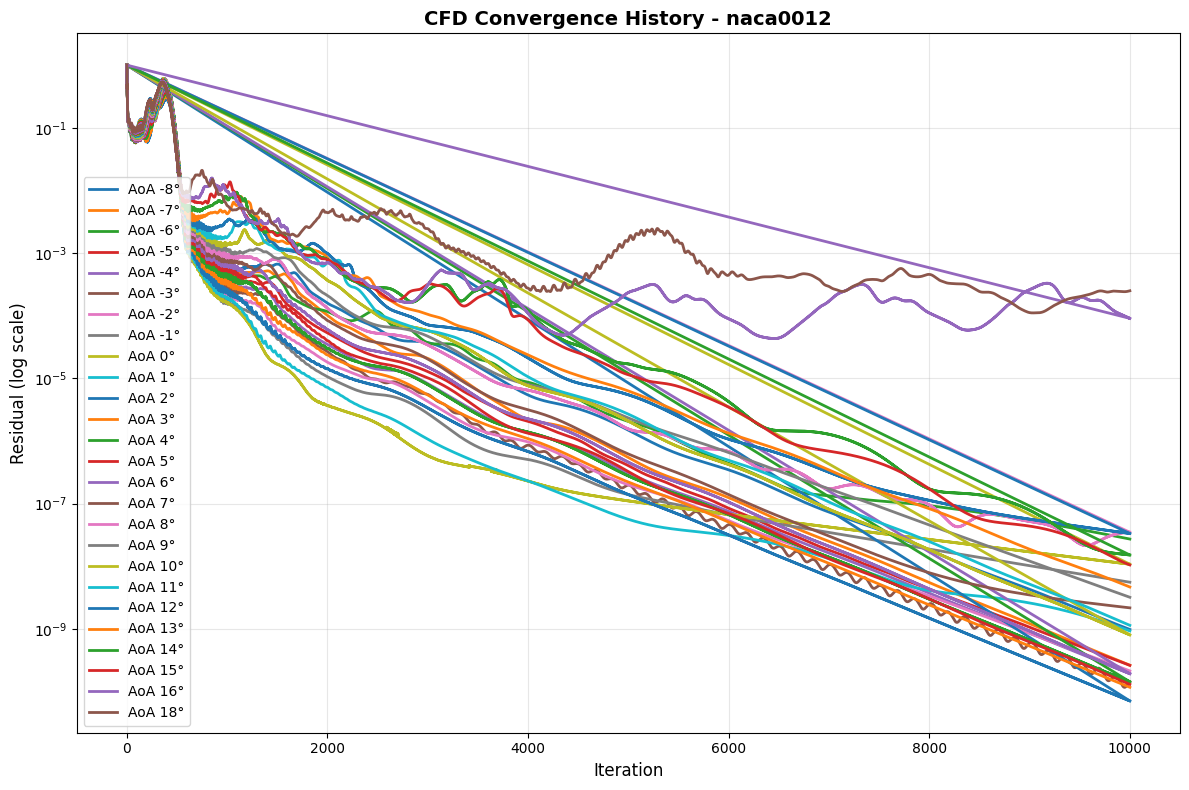

In [36]:
# Check convergence for all angles of attack in a single plot
# Automatically detect AoA folders
profile_dir = f'../{profile}/runs'
aoa_folders = [d for d in os.listdir(profile_dir) if os.path.isdir(os.path.join(profile_dir, d)) and d.startswith('aoa')]

# Extract angle values and sort (handle both positive and negative angles)
aoa_list = []
for folder in aoa_folders:
    # Match aoa-N for negative angles or aoaN for positive angles
    match = re.match(r'aoa(-?\d+)', folder)
    if match:
        aoa_list.append(int(match.group(1)))
aoa_list.sort()

print(f'Found {len(aoa_list)} angle of attack cases: {aoa_list}')

fig, ax = plt.subplots(figsize=(12, 8))

print(f'\nChecking convergence for {profile}')
print('='*60)

for angle in aoa_list:
    stats = pd.read_csv(f'../{profile}/runs/aoa{angle}/stats.csv')
    ax.semilogy(stats['iter'], stats['rho'], label=f'AoA {angle}°', linewidth=2)
    
    # Print convergence info
    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual
    
    status = '✓' if reduction < 1e-4 else '⚠'
    print(f'{status} AoA {angle:2d}°: {initial_residual:.2e} → {final_residual:.2e} (reduction: {reduction:.2e})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Residual (log scale)', fontsize=12)
ax.set_title(f'CFD Convergence History - {profile}', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{profile}/convergence.png', dpi=300)

In [37]:
# Use detected AoA list (assumes previous cell was run)
aoa = np.array(aoa_list)
cl = [extract_cl(f'../{profile}/runs/aoa{a}/force_airfoil.csv', tol=5e-4) for a in aoa]

Warning, cl is not converged : ../naca0012/runs/aoa16/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa18/force_airfoil.csv


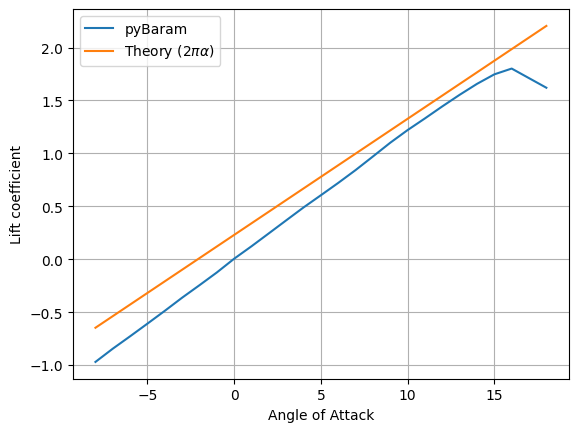

In [38]:
fig, ax = plt.subplots()
ax.plot(aoa, cl)
ax.plot(aoa, 2*np.pi*np.deg2rad(aoa + 2.1))
ax.set_xlabel('Angle of Attack')
ax.set_ylabel('Lift coefficient')
ax.legend(['pyBaram', r'Theory ($2\pi\alpha$)'])
ax.grid()
fig.savefig(f'{profile}/cl.png', dpi=300)